<a href="https://colab.research.google.com/github/anastasiatam/Master-s-Project/blob/main/GLCM_feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops
from google.colab import drive
import matplotlib.pyplot as plt

In [10]:
# Gather images

drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/mastersproject/10imagesamples'

valid_extensions = ('.jpg', '.png', '.jpeg', '.bmp', '.tif', '.tiff')
image_files = [
    os.path.join(folder_path, f)
    for f in os.listdir(folder_path)
    if f.lower().endswith(valid_extensions)
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Folder exists! Found 10 total files/items inside:
['300_0.3_C002H001S0001003865.bmp', '300_0.3_C002H001S0001003872.bmp', '300_0.3_C002H001S0001003870.bmp', '300_0.3_C002H001S0001003871.bmp', '300_0.3_C002H001S0001003876.bmp', '300_0.3_C002H001S0001003874.bmp', '300_0.3_C002H001S0001003866.bmp', '300_0.3_C002H001S0001003873.bmp', '300_0.3_C002H001S0001003877.bmp', '300_0.3_C002H001S0001003875.bmp']

image files count: 10


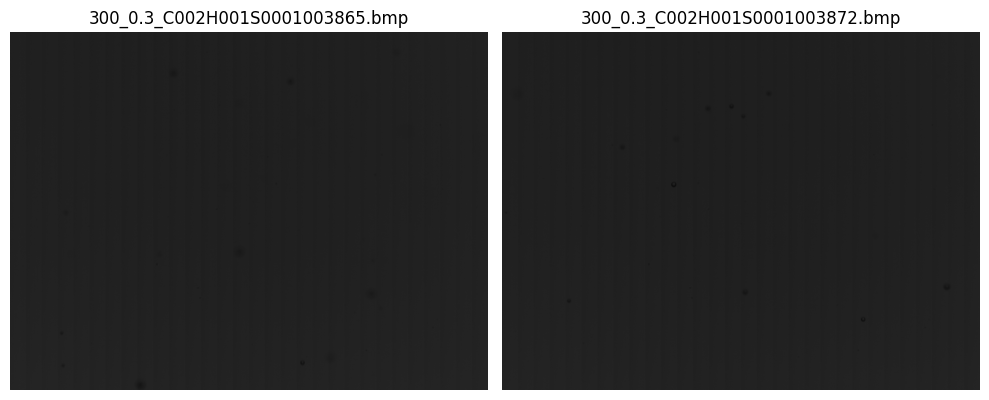

In [13]:
# Check if path exists
if not os.path.exists(folder_path):
    print(f"Error: Path does not exist: {folder_path}")
    print("\nContents of '/content/drive/MyDrive/mastersproject':")
    parent_dir = '/content/drive/MyDrive/mastersproject'
    if os.path.exists(parent_dir):
        print(os.listdir(parent_dir))
    else:
        print("Parent directory not found either. Check 'mastersproject' folder name.")
else:
    all_files = os.listdir(folder_path)
    print(f"Folder exists! Found {len(all_files)} total files/items inside:")
    print(all_files[:10])  # Print first 10 items to inspect extensions/names

    # Filter with case-insensitive extension check
    valid_extensions = ('.jpg', '.png', '.jpeg', '.bmp', '.tif', '.tiff')
    image_files = [
        os.path.join(folder_path, f)
        for f in all_files
        if f.lower().endswith(valid_extensions)
    ]

    print(f"\nimage files count: {len(image_files)}")

    # Display first 2 images
    if len(image_files) > 0:
        num_to_show = min(2, len(image_files))
        fig, axes = plt.subplots(1, num_to_show, figsize=(10, 5))

        if num_to_show == 1:
            axes = [axes]

        for i in range(num_to_show):
            img_path = image_files[i]
            filename = os.path.basename(img_path)

            img = cv2.imread(img_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i].imshow(img_rgb)
                axes[i].set_title(filename)
                axes[i].axis('off')
            else:
                print(f"Could not read image with OpenCV: {filename}")

        plt.tight_layout()
        plt.show()

In [21]:
# Offsets and orientations
distances = [1, 3, 5]  # Evaluates neighbors 1, 3, and 5 pixels away
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

results = []

In [28]:
for img_path in tqdm(image_files, desc="Processing Images"):
    filename = os.path.basename(img_path)

    # Read image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    # Compute GLCM
    glcm = graycomatrix(img, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)

    row_data = {'filename': filename}

    # Built-in scikit-image properties
    for prop in ['contrast', 'correlation', 'homogeneity', 'energy']:
      val = graycoprops(glcm, prop)
      row_data[f'glcm_{prop}_mean'] = np.mean(val)
      row_data[f'glcm_{prop}_std'] = np.std(val)  # Captures texture directionality

    # Compute entropy for each (distance, angle) matrix independently
    entropy_list = []
    for d_idx in range(len(distances)):
        for a_idx in range(len(angles)):
            # Slice the 2D GLCM for specific distance and angle
            p = glcm[:, :, d_idx, a_idx]
            p_non_zero = p[p > 0]
            # Calculate Shannon entropy on valid probabilities (which sum to 1.0)
            entropy_slice = -np.sum(p_non_zero * np.log2(p_non_zero))
            entropy_list.append(entropy_slice)

    # Mean and Std across all distance/angle combinations
    row_data['glcm_entropy_mean'] = np.mean(entropy_list)
    row_data['glcm_entropy_std'] = np.std(entropy_list)

    results.append(row_data)

Processing Images: 100%|██████████| 10/10 [00:02<00:00,  4.36it/s]


In [30]:
# Save to DataFrame
df_features = pd.DataFrame(results)

# Reorder columns explicitly to match the updated feature names
columns_order = [
    'filename',
    'glcm_contrast_mean', 'glcm_contrast_std',
    'glcm_correlation_mean', 'glcm_correlation_std',
    'glcm_homogeneity_mean', 'glcm_homogeneity_std',
    'glcm_energy_mean', 'glcm_energy_std',
    'glcm_entropy_mean', 'glcm_entropy_std'
]
df_features = df_features[columns_order]

# Display preview
display(df_features.head())

# Save CSV back to Drive folder
output_csv_path = os.path.join(folder_path, 'glcm_5_features.csv')
df_features.to_csv(output_csv_path, index=False)
print(f"\nFeatures saved to: {output_csv_path}")

,filename,glcm_contrast_mean,glcm_contrast_std,glcm_correlation_mean,glcm_correlation_std,glcm_homogeneity_mean,glcm_homogeneity_std,glcm_energy_mean,glcm_energy_std,glcm_entropy_mean,glcm_entropy_std
0,300_0.3_C002H001S0001003865.bmp,1.895767,0.312398,0.631679,0.060518,0.560539,0.031955,0.204670,0.007262,NaN,NaN
1,300_0.3_C002H001S0001003872.bmp,1.879514,0.301728,0.629059,0.059406,0.563255,0.032327,0.207188,0.007390,NaN,NaN
2,300_0.3_C002H001S0001003870.bmp,1.916944,0.300934,0.718425,0.044154,0.560318,0.031885,0.204103,0.007257,NaN,NaN
3,300_0.3_C002H001S0001003871.bmp,1.882256,0.309822,0.641547,0.058859,0.561940,0.032391,0.206076,0.007404,NaN,NaN
4,300_0.3_C002H001S0001003876.bmp,1.902844,0.301714,0.633844,0.057917,0.561521,0.031982,0.206466,0.007285,NaN,NaN



Features saved to: /content/drive/MyDrive/mastersproject/10imagesamples/glcm_5_features.csv
